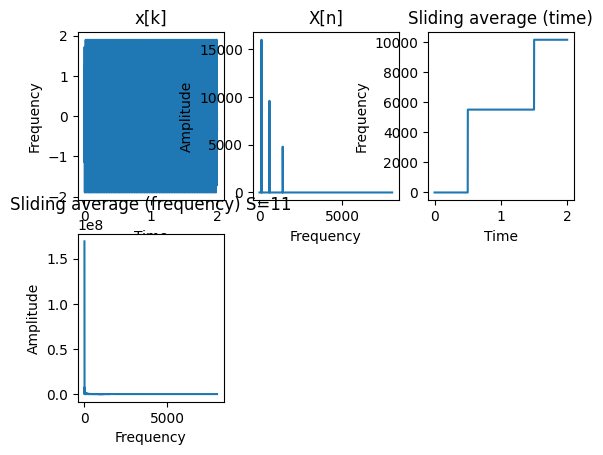

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

subplot_rows, subplot_cols = 2,2

fs = 8000 # Hz
duration = 2 # s
N = fs*duration
sampling_rate = 1/N

time = np.arange(0, duration, sampling_rate)

f1, f2, f3 = 120, 600, 1400
A1, A2, A3 = 1, 0.6, 0.3

signal = []
for i in time:
    signal.append(A1 * np.sin(2*np.pi* f1 *i) +
                  A2 * np.sin(2*np.pi* f2 *i) +
                  A3 * np.sin(2*np.pi* f3 *i))

plt.subplot(subplot_rows,subplot_cols,1)
plt.plot(time, signal, label="12Hz sine waves")
plt.title("x[k]")
plt.xlabel("Time")
plt.ylabel("Frequency")
# plt.show()

fft_coeffs = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(signal), d=sampling_rate)
# plt.plot(frequencies, fft_coeffs)
plt.subplot(subplot_rows,subplot_cols,2)
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_coeffs)[:len(frequencies)//2])
plt.title("X[n]")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")

# Sliding average
S = 1
def conv_sum(signal, S, k):
    res = 0
    for j in np.arange(math.ceil(k-S/2), math.ceil(k+S/2), sampling_rate):
        res += signal[int(j)]
    return res
x_k = [1/S*conv_sum(signal, S, k) for k in time]
plt.subplot(subplot_rows,subplot_cols,3)
plt.plot(time, x_k)
plt.title("Sliding average (time)")
plt.xlabel("Time")
plt.ylabel("Frequency")

# h[k]
h_k = [1/S if (0<=m and m<=S-1) else 0 for m in signal]

fft_coeffs = np.fft.fft(x_k)
frequencies = np.fft.fftfreq(len(x_k), d=sampling_rate)
plt.subplot(subplot_rows,subplot_cols,4)
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_coeffs)[:len(frequencies)//2])
plt.title("Sliding average (frequency) S=11")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()


# Spectrogramme

/tmp/ipykernel_146441/1577463727.py:2: UserWarning: Only one segment is calculated since parameter NFFT (=256) >= signal length (=3).
  plt.specgram(spec_signal)


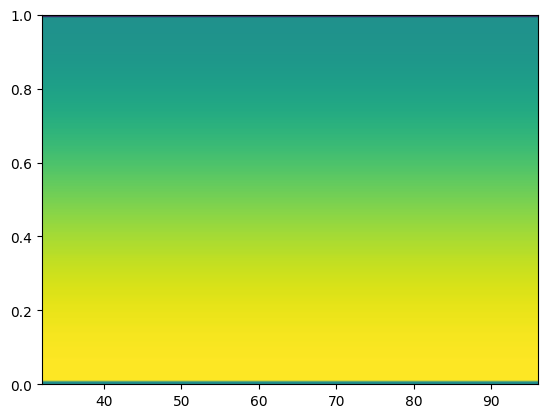

In [ ]:
spec_signal =
plt.specgram(spec_signal)
plt.show()